# Load data

TensorFlow: 2.20.0
Train: (6400, 28, 28, 1) Val: (1600, 28, 28, 1) Test: (2000, 28, 28, 1)


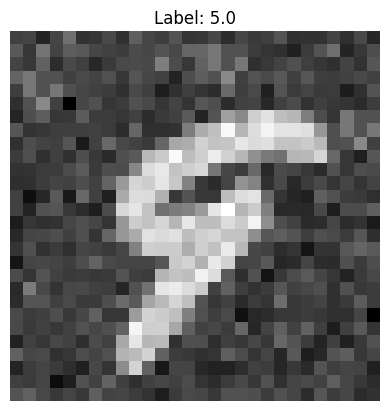

In [1]:
# 1) Imports & Reproducibility (Fixed)
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf


SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)

# 2) Load Data (Fixed)
# Expects a pickle file 'mnist.hupsista' containing (X, y) as numpy arrays.
with open('mnist.hupsista','rb') as f:
    X_all, y_all = pickle.load(f)

X_all = X_all.astype('float32')
# Normalize to [0,1]
if X_all.max() > 1.0:
    X_all /= 255.0
# Ensure channel dimension
if X_all.ndim == 3:
    X_all = X_all[..., None]

unique_labels = np.unique(y_all)

# 3) Create Train/Val/Test Splits (Fixed)
# Hold-out test once; then split train/val from the remainder.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()



# Start to build a Model
- My goal is build the model that not only high accuracy but also has low total params, for getting higher Net_score in the end.

1. Model 1
- using Conv2d and Maxpooling
- accuracy : 0.5020
- params ab 26,698. let's try to decrease it.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,698 (104.29 KB)

 Trainable params: 26,698 (104.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2567 - loss: 2.1424 - val_accuracy: 0.3756 - val_loss: 1.9583
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4250 - loss: 1.8546 - val_accuracy: 0.4306 - val_loss: 1.8346
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4648 - loss: 1.7268 - val_accuracy: 0.4631 - val_loss: 1.7337
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4794 - loss: 1.6122 - val_accuracy: 0.4787 - val_loss: 1.6571
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5020 - loss: 1.5180 - val_accuracy: 0.4812 - val_loss: 1.5988
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5219 - loss: 1.4309 - val_accuracy: 0.4837 - val_loss: 1.5443
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5336 - loss: 1.3571 - val_accuracy: 0.4894 - val_loss: 1.5041
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5561 - loss: 1.2935 - val_accuracy: 0.

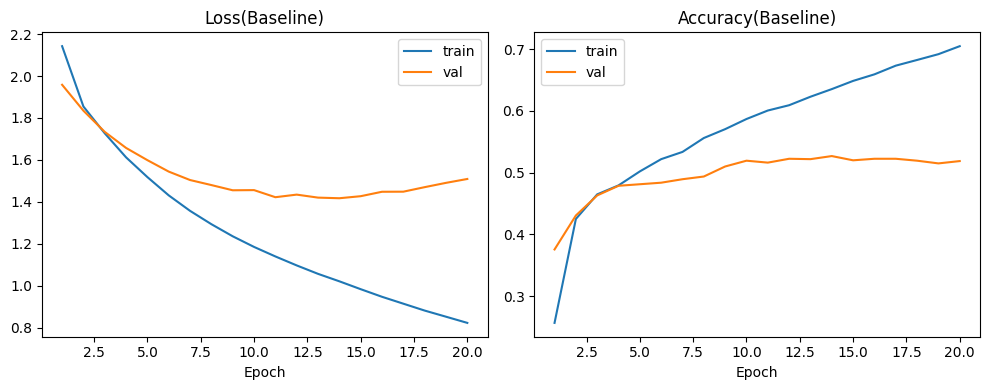

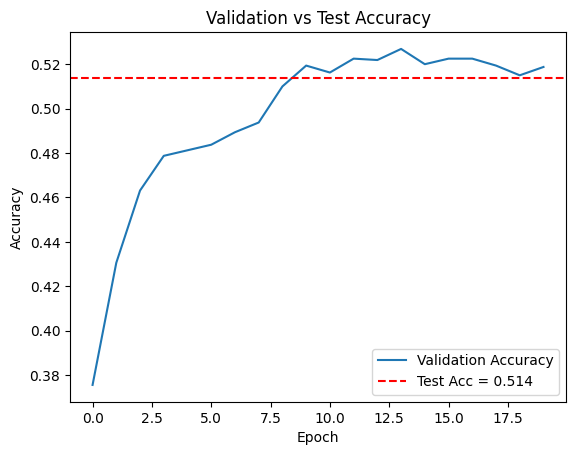

Final Test Accuracy: 0.5140
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [2]:
from tensorflow.keras import layers, models
# 5. build model1
model1 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1.summary()

# 6. train model
#fit
history = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model1.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

# 7. save model
model1.save("beam_model1.keras")
tf.keras.utils.plot_model(
    model1,
    to_file="model1_diagram.png",
    show_shapes=True
)


# model 2
- Normally, after using Convolution classes to extract features, we often use the Flatten() class to flatten the data and then append it to the Dense class. This method dramatically increases the number of parameters.

Instead of flattening all pixels into a long row, GAP calculates the average of an entire "feature map". 
- If we have an output from the Conv layer of $(7, 7, 64)$ (i.e., 64 images of size $7 \times 7$), 
- Flatten() will produce: 7*7*64 = 3,136 nodes.
- GlobalAveragePooling2D() will only produce: 64 nodes (each node being the average of a $7 \times 7$ image).


Final Test Accuracy: 0.2205 <br>
Total params: 1,690 <br>

toal params kinda low compare with model 1. but the accuracy not good.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,690 (6.60 KB)

 Trainable params: 1,690 (6.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1222 - loss: 2.2911 - val_accuracy: 0.1287 - val_loss: 2.2798
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1266 - loss: 2.2676 - val_accuracy: 0.1500 - val_loss: 2.2590
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1528 - loss: 2.2400 - val_accuracy: 0.1625 - val_loss: 2.2364
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1713 - loss: 2.2149 - val_accuracy: 0.1850 - val_loss: 2.2115
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1805 - loss: 2.1894 - val_accuracy: 0.1850 - val_loss: 2.1864
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1877 - loss: 2.1659 - val_accuracy: 0.1975 - val_loss: 2.1639
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1953 - loss: 2.1426 - val_accuracy: 0.2025 - val_loss: 2.1433
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2081 - loss: 2.1212 - val_accuracy: 0.

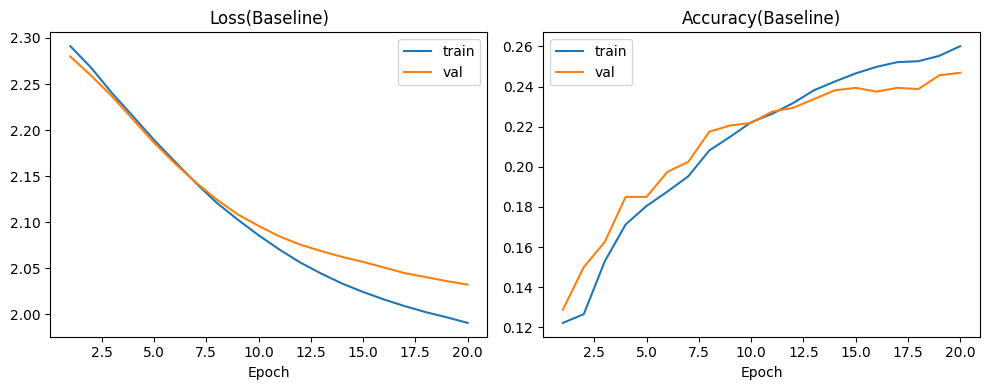

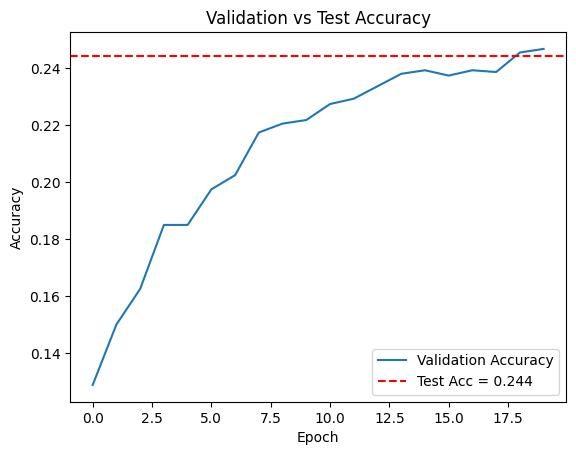

Final Test Accuracy: 0.2445
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [3]:
from tensorflow.keras import layers, models
# 5. build model
model2 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(16, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

# 6. train model
#fit
history = model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model2.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

# 7. save model
model2.save("beam_model2.keras")
tf.keras.utils.plot_model(
    model2,
    to_file="model2_diagram.png",
    show_shapes=True
)


# Model 3:
- add early stopping
- reduce the param in dense lauer, campare with first model
<br>
Total params: 13,978 <br>
Final Test Accuracy: 0.2205

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,978 (54.60 KB)

 Trainable params: 13,978 (54.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1906 - loss: 2.1757 - val_accuracy: 0.3094 - val_loss: 1.9818
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3864 - loss: 1.8783 - val_accuracy: 0.4238 - val_loss: 1.8049
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4516 - loss: 1.7289 - val_accuracy: 0.4625 - val_loss: 1.7221
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4834 - loss: 1.6365 - val_accuracy: 0.4769 - val_loss: 1.6625
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5003 - loss: 1.5730 - val_accuracy: 0.4837 - val_loss: 1.6273
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5081 - loss: 1.5220 - val_accuracy: 0.4913 - val_loss: 1.5990
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5163 - loss: 1.4797 - val_accuracy: 0.4888 - val_loss: 1.5761
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5241 - loss: 1.4422 - val_accuracy: 0.

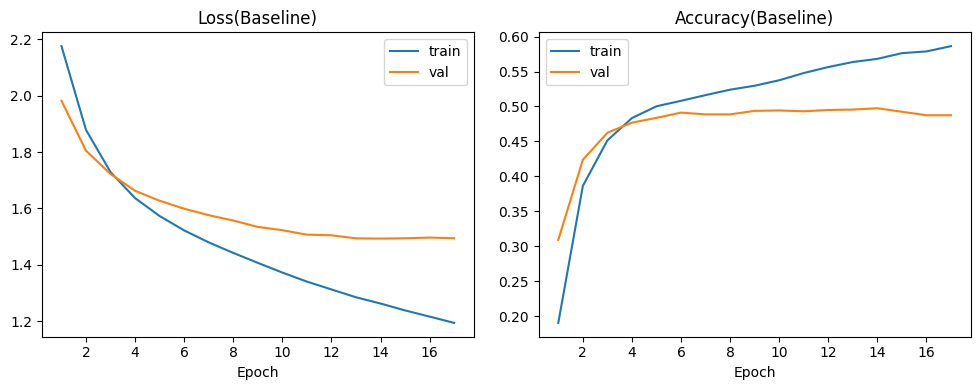

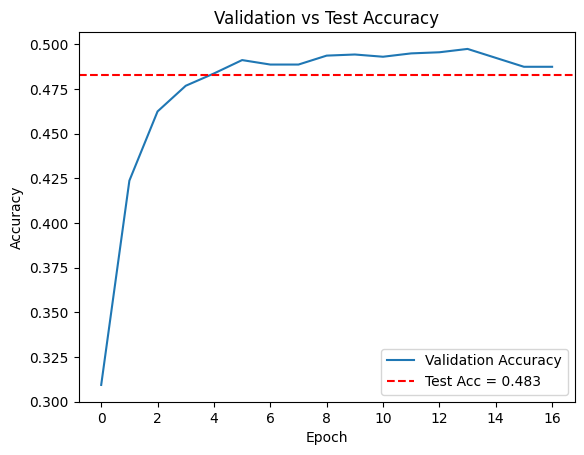

Final Test Accuracy: 0.4830
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [4]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
# 5. build model
model3 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model3.summary()


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
# 6. train model
#fit
history = model3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[early_stop]
)

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model3.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

# 7. save model
model3.save("beam_model3.keras")
tf.keras.utils.plot_model(
    model3,
    to_file="model3_diagram.png",
    show_shapes=True
)


# Model 4
- Final Test Accuracy: 0.5400
- params 18,188 

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 18)       │         3,618 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 18)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 48)             │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,188 (71.05 KB)

 Trainable params: 18,188 (71.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1963 - loss: 2.2039 - val_accuracy: 0.3981 - val_loss: 1.9969
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3605 - loss: 1.9607 - val_accuracy: 0.4556 - val_loss: 1.7970
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4025 - loss: 1.8608 - val_accuracy: 0.4806 - val_loss: 1.7323
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4158 - loss: 1.7841 - val_accuracy: 0.4831 - val_loss: 1.6444
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4411 - loss: 1.6913 - val_accuracy: 0.4913 - val_loss: 1.5549
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4666 - loss: 1.6178 - val_accuracy: 0.5019 - val_loss: 1.4723
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4733 - loss: 1.5492 - val_accuracy: 0.5088 - val_loss: 1.4130
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4973 - loss: 1.4782 - val_accuracy: 0.

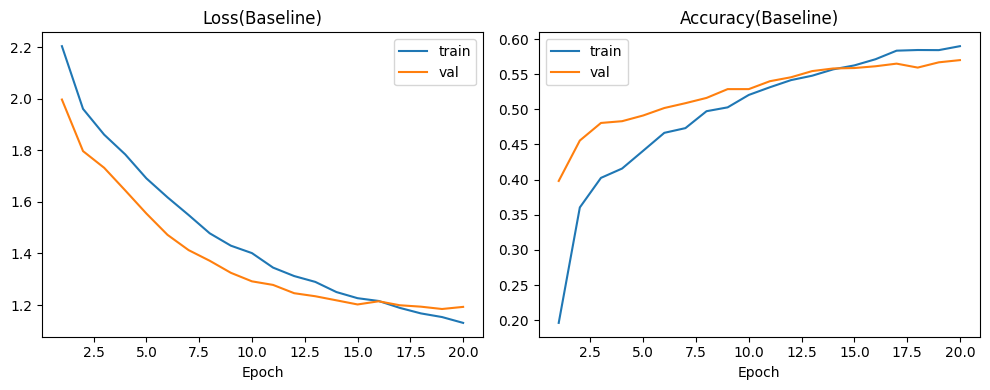

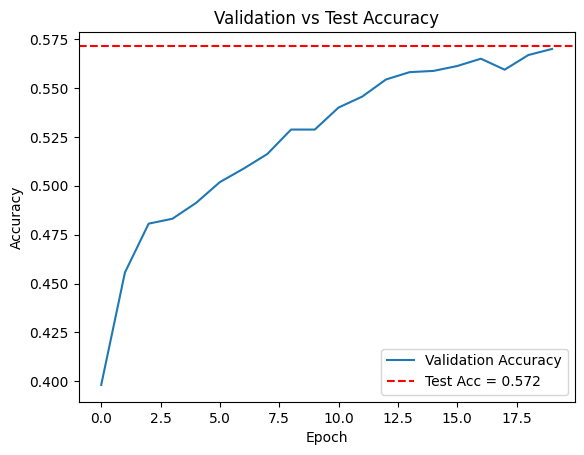

Final Test Accuracy: 0.5715
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [5]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
# 5. build model
model4 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(filters=8, kernel_size=5, activation="relu"), 
    layers.MaxPool2D(pool_size=2),
    
    tf.keras.layers.Conv2D(18, 5, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    
    layers.Flatten(),
    
    tf.keras.layers.Dense(48, activation="relu"), 
    layers.Dropout(0.5), 
    

    layers.Dense(10, activation='softmax')
])

model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model4.summary()


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
# 6. train model
#fit
history = model4.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[early_stop]
)

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model4.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

# 7. save model
model4.save("beam_model4.keras")
tf.keras.utils.plot_model(
    model4,
    to_file="model4_diagram.png",
    show_shapes=True
)


# Model 5
- adding ReduceLROnPlateau

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 18)       │         3,618 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 18)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 48)             │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,596 (76.55 KB)

 Trainable params: 19,596 (76.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1770 - loss: 2.2105 - val_accuracy: 0.3669 - val_loss: 1.9700 - learning_rate: 0.0010
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3314 - loss: 2.0010 - val_accuracy: 0.4338 - val_loss: 1.8548 - learning_rate: 0.0010
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3780 - loss: 1.9082 - val_accuracy: 0.4588 - val_loss: 1.7830 - learning_rate: 0.0010
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4189 - loss: 1.8227 - val_accuracy: 0.4819 - val_loss: 1.6819 - learning_rate: 0.0010
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4367 - loss: 1.7098 - val_accuracy: 0.4900 - val_loss: 1.5289 - learning_rate: 0.0010
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4564 - loss: 1.5968 - val_accuracy: 0.5050 - val_loss: 1.4283 - learning_rate: 0.0010
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4719 - loss: 1.5272 - 

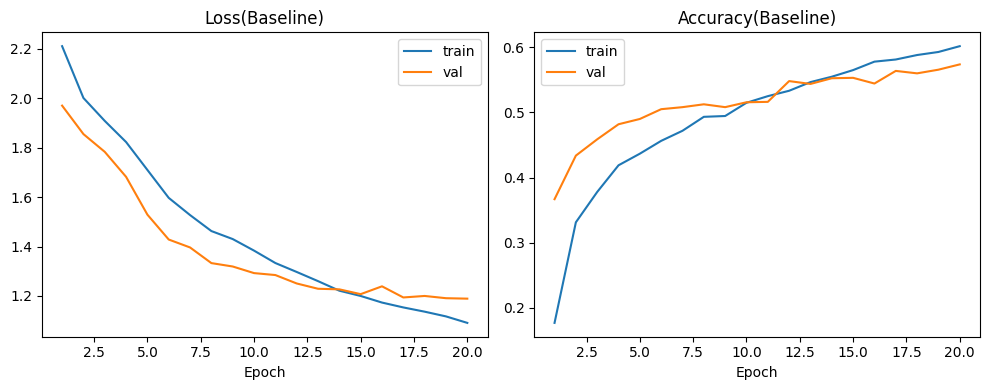

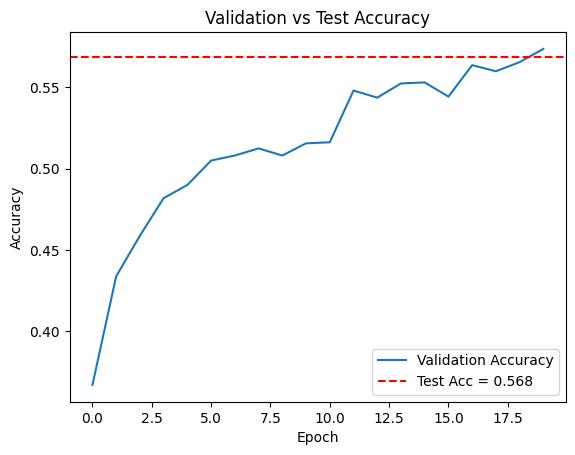

Final Test Accuracy: 0.5685


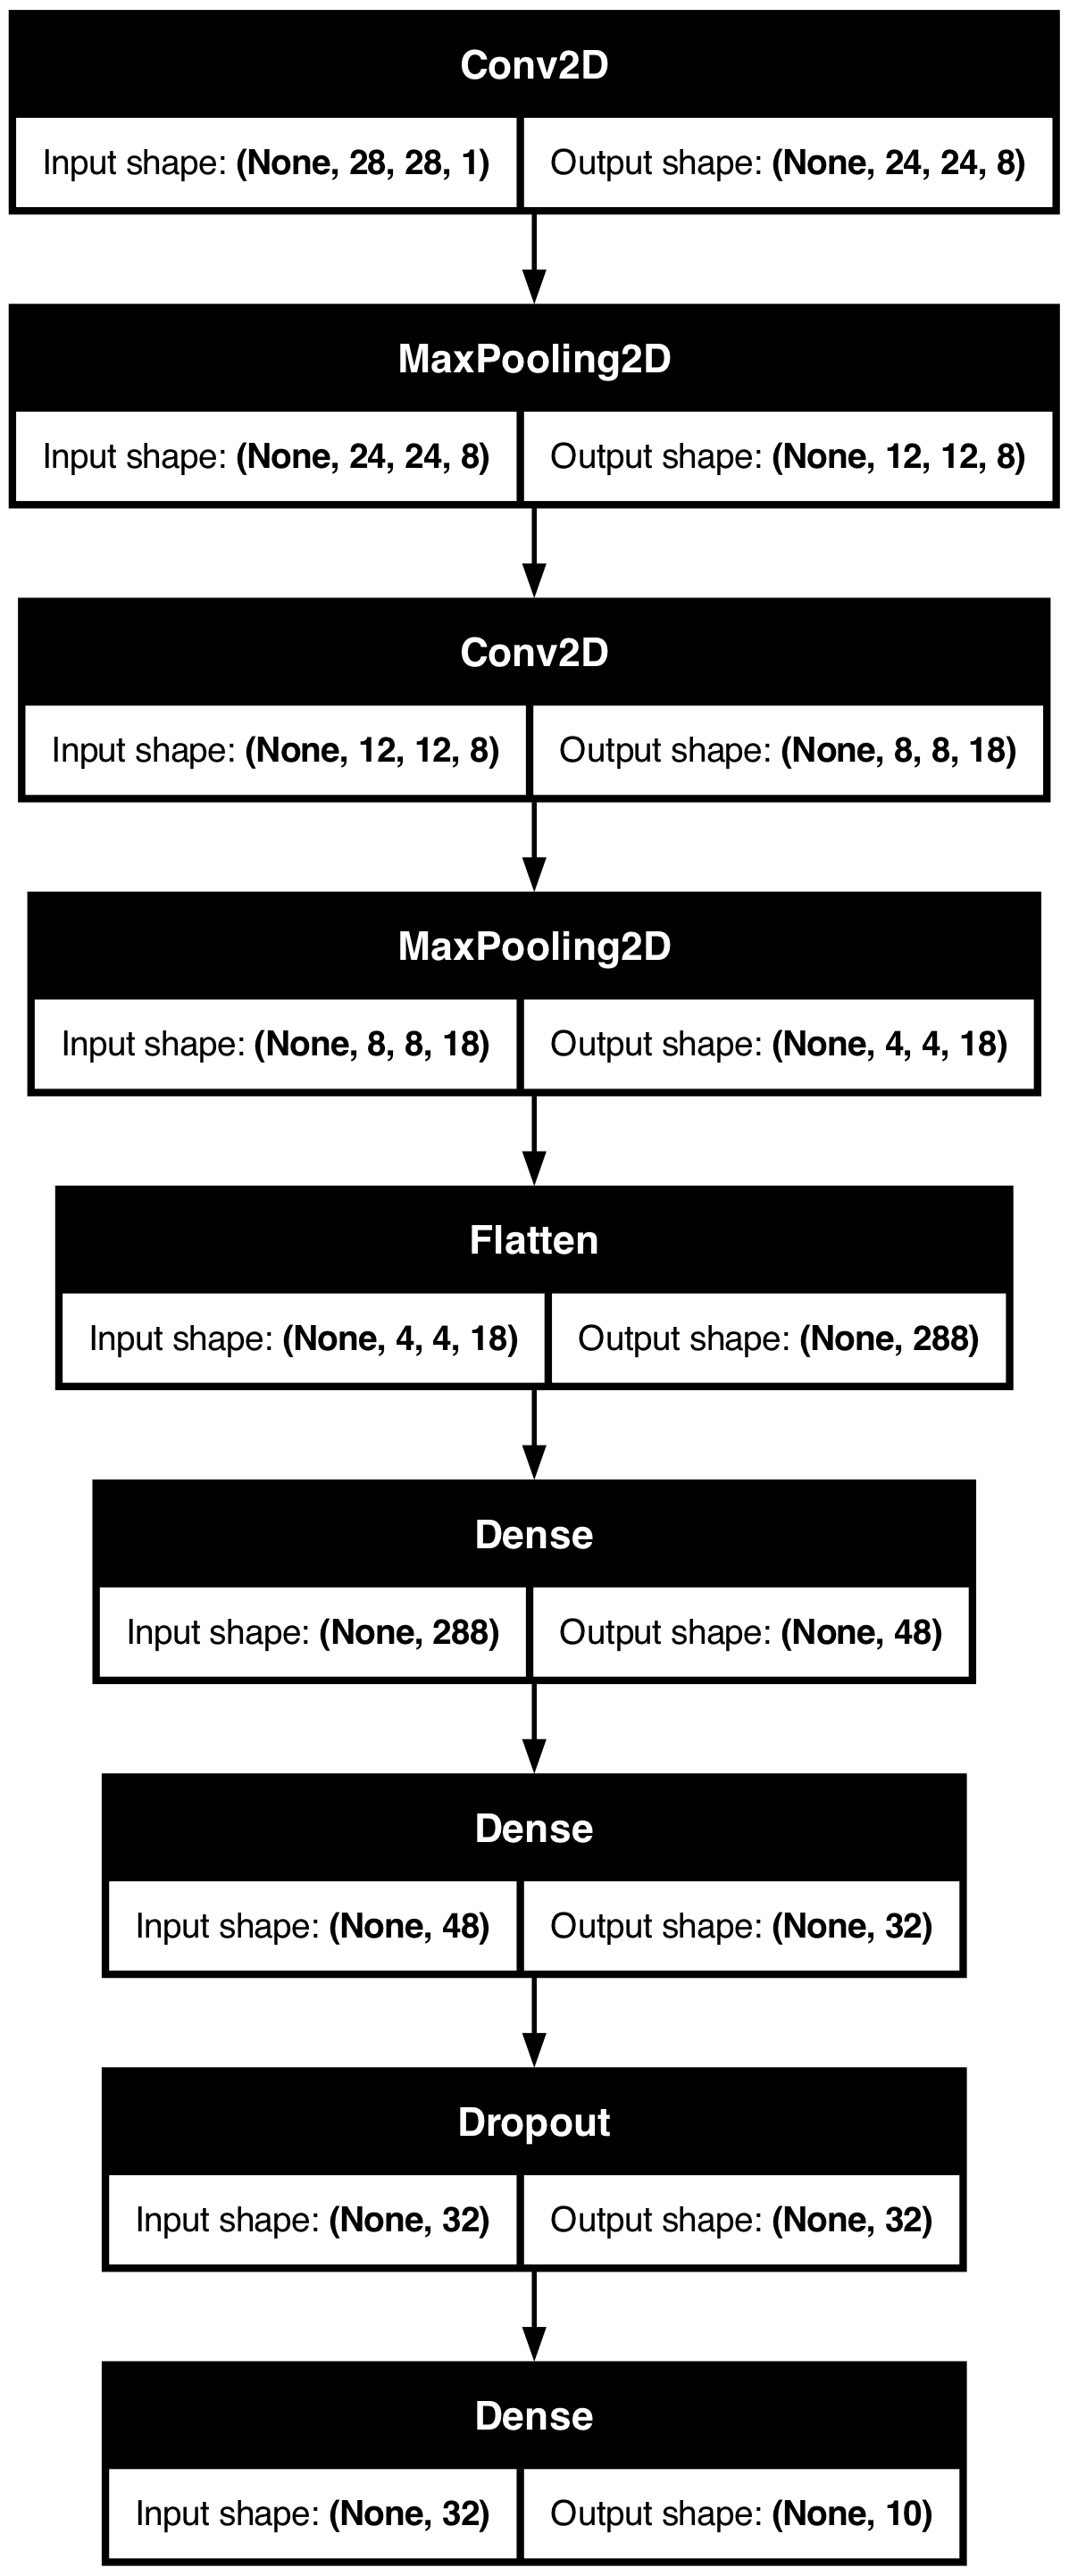

In [14]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# 5. build model
model5 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(filters=8, kernel_size=5, activation="relu"), 
    layers.MaxPool2D(pool_size=2),
    
    tf.keras.layers.Conv2D(18, 5, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    
    layers.Flatten(),
    tf.keras.layers.Dense(48, activation="relu"), 
    tf.keras.layers.Dense(32, activation="relu"), 
    layers.Dropout(0.5), 
    

    layers.Dense(10, activation='softmax')
])

model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model5.summary()


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)
# 6. train model
#fit
history = model5.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[early_stop,reduce_lr]
)

def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model5.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')

# 7. save model
model5.save("beam_model5.keras")
tf.keras.utils.plot_model(
    model5,
    to_file="model5_diagram.png",
    show_shapes=True
)

import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
from IPython.display import Image
Image("model5_diagram.png")



In [7]:
# 8. fuction for net score
def money(model, X_test_data, y_test_labels):
    predictions = model.predict(X_test_data, verbose=0)
    y_pred = np.argmax(predictions, axis=1)

    n_correct = np.sum(y_pred == y_test_labels)

    if n_correct <= 5000:
        reward = n_correct * 100
    elif n_correct <= 6000:
        reward = (5000 * 100) + (n_correct - 5000) * 200
    else:
        reward = (5000 * 100) + (1000 * 200) + (n_correct - 6000) * 1000

    total_params = model.count_params()
    net_score = reward - total_params

    print(f"correct: {n_correct}/{len(y_test_labels)}")
    print(f"Accuracy: {n_correct / len(y_test_labels):.4f}")
    print(f"reward: {reward} €")
    print(f"Total params: {total_params}")
    print(f"NET SCORE: {net_score}")

    return net_score

In [8]:
print("model1")
#evaluate model using the net score function
# all data
model = tf.keras.models.load_model("beam_model1.keras")
final_score = money(model, X_all, y_all)

print("-"*30)

#test data
final_score = money(model, X_test, y_test)

model1
correct: 6437/10000
Accuracy: 0.6437
reward: 1137000 €
Total params: 26698
NET SCORE: 1110302
------------------------------
correct: 1028/2000
Accuracy: 0.5140
reward: 102800 €
Total params: 26698
NET SCORE: 76102


In [9]:
print("model2")
#evaluate model using the net score function
# all data
model = tf.keras.models.load_model("beam_model2.keras")
final_score = money(model, X_all, y_all)

print("-"*30)

#test data
final_score = money(model, X_test, y_test)

model2
correct: 2528/10000
Accuracy: 0.2528
reward: 252800 €
Total params: 1690
NET SCORE: 251110
------------------------------
correct: 489/2000
Accuracy: 0.2445
reward: 48900 €
Total params: 1690
NET SCORE: 47210


In [10]:
print("Model3")

model = tf.keras.models.load_model("beam_model3.keras")
final_score = money(model, X_all, y_all)
print("-"*30)
model = tf.keras.models.load_model("beam_model3.keras")
final_score = money(model, X_test, y_test)

Model3
correct: 5472/10000
Accuracy: 0.5472
reward: 594400 €
Total params: 13978
NET SCORE: 580422
------------------------------
correct: 966/2000
Accuracy: 0.4830
reward: 96600 €
Total params: 13978
NET SCORE: 82622


In [11]:
print("Model4")

model = tf.keras.models.load_model("beam_model4.keras")
final_score = money(model, X_all, y_all)
print("-"*30)
model = tf.keras.models.load_model("beam_model4.keras")
final_score = money(model, X_test, y_test)

Model4
correct: 6284/10000
Accuracy: 0.6284
reward: 984000 €
Total params: 18188
NET SCORE: 965812
------------------------------
correct: 1143/2000
Accuracy: 0.5715
reward: 114300 €
Total params: 18188
NET SCORE: 96112


In [12]:
print("Model5")

model = tf.keras.models.load_model("beam_model5.keras")
final_score = money(model, X_all, y_all)
print("-"*30)
model = tf.keras.models.load_model("beam_model5.keras")
final_score = money(model, X_test, y_test)

Model5
correct: 6263/10000
Accuracy: 0.6263
reward: 963000 €
Total params: 19596
NET SCORE: 943404
------------------------------
correct: 1172/2000
Accuracy: 0.5860
reward: 117200 €
Total params: 19596
NET SCORE: 97604


In [13]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
!dot -V
import pydot

dot - graphviz version 14.1.3 (20260303.0454)
